In [ ]:
# autograd(자동미분)

In [2]:
import torch

x = torch.tensor([1.],requires_grad=True)
print(x)

"""
x = 1.0인 스칼라 텐서이며,

requires_grad=True는 PyTorch에게
→ "이 변수는 미분 대상이야!" 라고 알려주는 거야.
→ 즉, 학습 가능한 파라미터로 설정한 것과 같아.
"""

tensor([1.], requires_grad=True)


In [5]:
x = torch.tensor([1.],requires_grad=True)
y = x**2
print(y)

"""
y = x²라는 연산을 정의.

이때 PyTorch는 자동으로 계산 그래프를 만듦.

x에서 y로 가는 연결(edge) 이 생김.
"""

print(x.grad)
y.backward()
print(x.grad) # y=x**2를 미분하여 x에 1 대입

tensor([1.], grad_fn=<PowBackward0>)
None
tensor([2.])


In [19]:
x = torch.tensor([1.],requires_grad=True)
y = x**2
print(y)
y.retain_grad() # 중간단계의 미분도 알수있다. retain : 유지한다

"""
tensor([1.], grad_fn=<PowBackward0>)
→ 값은 1이고, PowBackward0은 **2 연산이었단 의미야.
→ grad_fn은 이 텐서가 어떤 연산으로 만들어졌는지를 기록해주는 기능이야.

기본적으로 중간 텐서(y)는 .grad 값이 저장되지 않음
.retain_grad()를 해줘야 .backward() 후에 y.grad에 미분 값이 남음
(중간값이 아니라 leaf가 아닌 텐서이기 때문에)
"""

z=3*y
print(z)

z.backward()
print(x.grad) # chain rule로 알아냄
print(y.grad)

"""
z를 기준으로 미분 수행

계산 그래프를 거꾸로(backward) 타고
각 변수에 대해 기울기(미분값) 를 자동으로 계산해줌
"""

# x가 leaf tensor z가 뿌리tensor y가 줄기tensor이다.
"""
x → 잎(leaf)

y = x² → 줄기

z = 3y → 뿌리(root)

z.backward()는 뿌리에서 시작해,
→ 줄기 → 잎 방향으로 미분값을 역전파(chain rule) 시켜주는 과정이야.

"""

tensor([1.], grad_fn=<PowBackward0>)
tensor([3.], grad_fn=<MulBackward0>)
tensor([6.])
tensor([3.])


'\nx → 잎(leaf)\n\ny = x² → 줄기\n\nz = 3y → 뿌리(root)\n\nz.backward()는 뿌리에서 시작해,\n→ 줄기 → 잎 방향으로 미분값을 역전파(chain rule) 시켜주는 과정이야.\n\n'

In [9]:
x = torch.tensor([1.],requires_grad=True)
y = torch.tensor([1.],requires_grad=True)
z = y*x**2
z.backward()
print(x.grad) # z를 x로 미분
print(y.grad)

tensor([2.])
tensor([1.])


In [14]:
x = torch.tensor([1.,2.,3.],requires_grad=True)
y = torch.sum(x**2) # x1**2 +x2**2 + x3**2
y.backward()

print(y)
print(x.grad) # 스칼라를 벡터로 미분

tensor(14., grad_fn=<SumBackward0>)
tensor([2., 4., 6.])


In [16]:
x = torch.tensor([1.,2.,3.],requires_grad=True)
x.requires_grad=False # transfer learning 할때 필요(학습된 모델이 있는데 학습된 모델의 일부분만 학습을 시키고싶을때 False로 놓고 고정하고 True만 미분대상으로 학습)

y = x**2
print(y) # 벡터에 관에서 미분후 대입해줌

tensor([1., 4., 9.])


In [15]:
x = torch.tensor([1.],requires_grad=True)
x.requires_grad=False # transfer learning 할때 필요

y = x**2
print(y) # 벡터에 관에서 미분후 대입해줌

tensor([1.])


In [18]:
# detach 사용 모드
x = torch.tensor([1.], requires_grad=True)
y = x**2
z=y.detach()
w = y+z

w.backward()
print(x.grad)

"""
계산 그래프 중간에서 .detach()를 사용하면
그 이후 연산은 그래디언트(미분)의 경로에서 분리됨.

w = y + z에서 z는 .detach()로 만들어졌기 때문에,
z는 역전파(gradient flow)에 영향을 주지 않음.
"""

tensor([2.])


'\n계산 그래프 중간에서 .detach()를 사용하면\n그 이후 연산은 그래디언트(미분)의 경로에서 분리됨.\n\nw = y + z에서 z는 .detach()로 만들어졌기 때문에,\nz는 역전파(gradient flow)에 영향을 주지 않음.\n'

In [21]:
# torch.no_grad()
x = torch.tensor([1.], requires_grad=True)

with torch.no_grad(): # 계산 그래프상에서 변수를 제외시키는것 역전파가 안되도록(자동 미분끔)
    y = x**2
    print(x.requires_grad)
    print(y)
print(x.requires_grad)

y=x**2
print(y)


True
tensor([1.])
True
tensor([1.], grad_fn=<PowBackward0>)


In [22]:
x = torch.tensor([1.], requires_grad=True)
x.requires_grad=False
y = x**2
print(x.requires_grad)
print(y) # 위 셀은 requires_grad를 잠시 False로 바꿔주는것이다 완전 False로 해서 없애는것이 아니라 (이렇게 False로 하면 그래프 추적 아예안됨 위처럼 하면 블록 빠져나오면 다시 복구됨)

True
tensor([1.], grad_fn=<PowBackward0>)


In [30]:
import os

os.environ["PATH"] += os.pathsep + "/opt/anaconda3/envs/brain_env1/bin"
  # 여기엔 which dot 결과 경로 입력

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


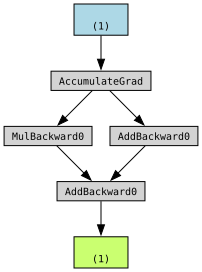

In [32]:
from torchviz import make_dot
x = torch.tensor([1.],requires_grad=True)
make_dot(x)
make_dot(x**2)
make_dot(x**2+1)
make_dot((x**2+1)**2)

y = 2*x
z = 3+x
r = y+z
make_dot(r)

In [33]:
r.backward()
print(x.grad)

tensor([3.])
